# Orientation Relationships: Fundamentals

This notebook is the entry point to PyTex's orientation-relationship (OR)
stack. Working through it you will:

- understand the **conventions** every OR computation in PyTex follows,
- build the **Kurdjumov-Sachs** (KS) relationship and read its `describe()`,
- generate and interpret its **24 variants**, the **intervariant
  misorientation spectrum**, and the **4 x 6 packet structure**,
- predict **variant pole figures** for a given parent orientation,
- measure **OR deviation** of observed children and **fit** the operative
  OR from parent/child pairs.

One relationship gives rise to three linked mathematical objects — the
rotation, the index correspondence, and the deformation:

![OR doctrine pipeline](../../_static/or/or_doctrine_pipeline.svg)

This notebook covers the *rotation* pillar; notebook 19 covers the
correspondence and deformation pillars, and notebook 20 the experimental
identification/reconstruction pipeline.


## Conventions and the core mathematics

**Orientations.** PyTex orientations are *crystal → specimen* rotations:
for a crystal-frame vector $v_c$, the specimen-frame image is
$v_s = g\,v_c$.

**The OR rotation.** An orientation relationship carries a rotation $R$
mapping *parent-crystal* vectors to *child-crystal* vectors. It is built
from a defining parallelism — a plane pair plus an in-plane direction
pair. For KS:

$$(111)_\gamma \parallel (011)_\alpha, \qquad
[\bar 1 0 1]_\gamma \parallel [\bar 1 \bar 1 1]_\alpha .$$

**The canonical composition.** If the parent grain has orientation
$g_p$, a child formed by variant $V_k$ has orientation

$$g_c = g_p \circ V_k^{\mathsf T},$$

which makes corresponding crystal directions coincide in specimen space:
$g_c\,(V_k v_p) = g_p\,v_p$.

**Variants.** The symmetry orbit $\{R\,S_p : S_p \in G_p\}$, deduplicated
by the child symmetry $G_c$ (one representative per left coset), gives the
distinct variants. The count is $|G_p| / |\text{stabilizer}|$ — 24 for KS,
12 for Nishiyama-Wassermann, 24 for Greninger-Troiano.

**Misorientation representative.** The single axis/angle number quoted for
an OR (e.g. "KS = 42.85° about ⟨0.968 0.178 0.178⟩") is the
*disorientation*: the minimal-angle member of the double coset
$G_c\,R\,G_p$.

![Variant generation algorithm](../../_static/or/variant_generation_algorithm.svg)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pytex import (
    CrystalDirection,
    CrystalPlane,
    FrameDomain,
    Handedness,
    Lattice,
    MillerIndex,
    Orientation,
    OrientationRelationship,
    OrientationSet,
    Phase,
    ReferenceFrame,
    Rotation,
    SymmetrySpec,
    fit_orientation_relationship,
    intervariant_misorientation_angles_deg,
    intervariant_misorientations,
    map_plane_across_variants,
    or_deviation,
    plot_variant_pole_figure,
    select_variants,
    standard_fcc_bcc_relationships,
    variant_close_packed_groups,
    variant_pole_figure,
)


def make_or_context():
    """Austenite (fcc) and ferrite/martensite (bcc) phases + a specimen frame."""
    parent_frame = ReferenceFrame(
        "austenite_crystal", FrameDomain.CRYSTAL, ("a", "b", "c"), Handedness.RIGHT
    )
    child_frame = ReferenceFrame(
        "martensite_crystal", FrameDomain.CRYSTAL, ("a", "b", "c"), Handedness.RIGHT
    )
    specimen = ReferenceFrame(
        "specimen", FrameDomain.SPECIMEN, ("x", "y", "z"), Handedness.RIGHT
    )
    austenite = Phase(
        "austenite",
        lattice=Lattice(3.60, 3.60, 3.60, 90.0, 90.0, 90.0, crystal_frame=parent_frame),
        symmetry=SymmetrySpec.from_point_group("m-3m", reference_frame=parent_frame),
        crystal_frame=parent_frame,
    )
    martensite = Phase(
        "martensite",
        lattice=Lattice(2.87, 2.87, 2.87, 90.0, 90.0, 90.0, crystal_frame=child_frame),
        symmetry=SymmetrySpec.from_point_group("m-3m", reference_frame=child_frame),
        crystal_frame=child_frame,
    )
    return austenite, martensite, specimen


In [2]:
austenite, martensite, specimen = make_or_context()
ks = OrientationRelationship.from_kurdjumov_sachs_correspondence(
    parent_phase=austenite, child_phase=martensite
)
print(ks.describe())


Orientation relationship 'kurdjumov_sachs': parent phase 'austenite' (m-3m) to child phase 'martensite' (m-3m).
Defining plane parallelism: (111) parent || (011) child.
Defining direction parallelism: [-101] parent || [-1-11] child.
Misorientation representative (child-symmetry and parent-symmetry reduced): 42.85 deg about <0.968 0.178 0.178> (axis components identical in both crystal frames).
Variants: 24 crystallographically distinct child orientations from one parent (child-symmetry reduced).


Every report object in the OR stack carries a `describe()` like the one
above: the conventions, the defining parallelisms in crystallographic
notation, the disorientation representative, and the variant count, all
stated in prose. If a number matters, `describe()` says where it comes
from.

## The 24 KS variants and the intervariant spectrum

Boundaries between children of the *same parent* can only take the
misorientations of variant pairs, $V_a V_b^{\mathsf T}$ (child-symmetry
reduced). This discrete spectrum — validated against the Morito et al.
table for KS — is the fingerprint used for OR identification in
notebook 20.


In [3]:
variants = ks.generate_variants()
print(f"KS variant count: {len(variants)}")

table = intervariant_misorientation_angles_deg(ks)
pairs = table[np.triu_indices(len(variants), k=1)]
unique_angles = np.unique(np.round(pairs, 2))
print(f"distinct intervariant angles (deg): {unique_angles}")


KS variant count: 24
distinct intervariant angles (deg): [10.53 14.88 20.61 21.06 47.11 49.47 50.51 51.73 57.21 60.  ]


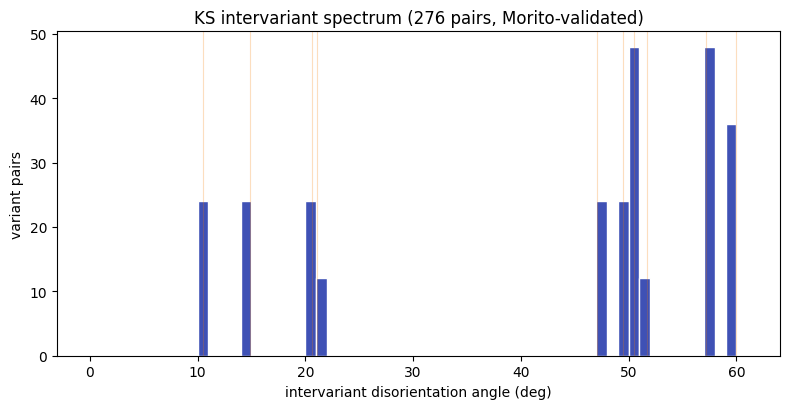

In [4]:
fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.hist(pairs, bins=np.arange(0.0, 62.0, 1.0), color="#3f51b5",
        edgecolor="white")
ax.set_xlabel("intervariant disorientation angle (deg)")
ax.set_ylabel("variant pairs")
ax.set_title("KS intervariant spectrum (276 pairs, Morito-validated)")
for angle in unique_angles:
    ax.axvline(angle, color="#f57c00", alpha=0.25, linewidth=0.8)
fig.tight_layout()


## Packets: variants grouped by close-packed plane

Each KS variant carries one member of the parent {111} family into exact
parallelism with the child close-packed plane. Grouping variants by that
member reproduces the lath-martensite **packet** hierarchy: four packets
of six variants.


In [5]:
packet_labels = variant_close_packed_groups(
    ks,
    CrystalPlane(MillerIndex(np.array([1, 1, 1]), phase=austenite),
                 phase=austenite),
)
print("packet label per variant:", packet_labels)
print("packet sizes:", np.bincount(packet_labels))


packet label per variant: [0 1 0 2 1 0 3 1 2 3 2 3 1 2 0 3 1 3 2 0 3 2 1 0]
packet sizes: [6 6 6 6]


## Variant pole figures

For a parent orientation $g_p$, each variant predicts child orientations
$g_c = g_p \circ V_k^{\mathsf T}$ and hence specimen-frame poles of any
child plane family. The overlay below is the standard tool for reading a
measured martensite {011} pole figure: every cluster belongs to a
variant, and missing clusters indicate variant selection.


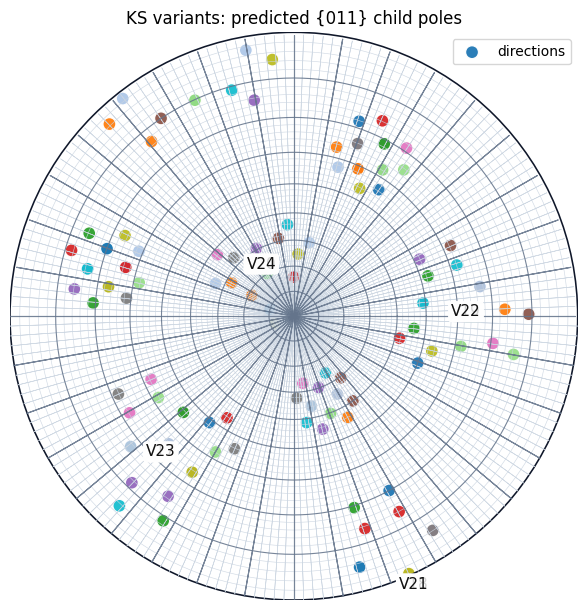

In [6]:
parent_orientation = Orientation.from_euler(
    20.0, 35.0, 50.0,
    specimen_frame=specimen,
    symmetry=austenite.symmetry,
    phase=austenite,
)
poles = variant_pole_figure(
    parent_orientation,
    ks,
    CrystalPlane(MillerIndex(np.array([0, 1, 1]), phase=martensite),
                 phase=martensite),
)
axes = plot_variant_pole_figure(
    poles, title="KS variants: predicted {011} child poles"
)


## OR deviation and fitting the operative relationship

Real microstructures rarely follow a textbook OR exactly. Two tools
quantify this:

- `or_deviation(parents, children, relationship)` — for each pair, the
  child-symmetry-reduced angle to the *nearest variant*:
  $\delta_i = \min_k \angle\!\left(C_i,\; P_i \circ V_k^{\mathsf T}\right)$,
- `fit_orientation_relationship(parents, children, nominal)` — an
  iterative quaternion eigen-mean (Markley) over the symmetry-aligned
  measured rotations $V_i = C_i^{\mathsf T} P_i$, recovering the operative
  rotation from data with a nominal OR only as the starting guess.

Below, children are built *exactly* from Greninger-Troiano (GT), then
analysed against KS: the deviation comes out at the documented KS-GT
separation (2.40°), and the fit recovers GT from the KS starting point.


In [7]:
gt = OrientationRelationship.from_greninger_troiano_correspondence(
    parent_phase=austenite, child_phase=martensite
)
rng = np.random.default_rng(20260718)
parent_set = OrientationSet.from_orientations([
    Orientation.from_euler(
        *angles, specimen_frame=specimen,
        symmetry=austenite.symmetry, phase=austenite,
    )
    for angles in rng.uniform(15.0, 75.0, size=(40, 3))
])
gt_variants = gt.generate_variants()
planted = rng.integers(0, len(gt_variants), size=len(parent_set))
children = OrientationSet.from_orientations([
    Orientation(
        rotation=parent_set[i].rotation.compose(
            gt_variants[int(k)].parent_to_child_rotation.inverse()
        ),
        crystal_frame=martensite.crystal_frame,
        specimen_frame=specimen,
        symmetry=martensite.symmetry,
        phase=martensite,
    )
    for i, k in enumerate(planted)
])

report = or_deviation(parent_set, children, gt)
print("deviation from the generating GT relationship:")
print(f"  mean {report.mean_deviation_deg:.4f} deg "
      f"(exact synthetic data -> 0)")
report_ks = or_deviation(parent_set, children, ks)
print("deviation of the same children from KS:")
print(f"  mean {report_ks.mean_deviation_deg:.4f} deg "
      f"(the documented KS-GT separation)")


deviation from the generating GT relationship:
  mean 0.0000 deg (exact synthetic data -> 0)
deviation of the same children from KS:
  mean 2.4037 deg (the documented KS-GT separation)


In [8]:
fit = fit_orientation_relationship(parent_set, children, ks)
print(fit.describe())


Fitted orientation relationship 'kurdjumov_sachs_fitted' from 40 parent/child pair(s), starting from nominal 'kurdjumov_sachs': converged in 2 iteration(s). Fitted misorientation representative: 44.23 deg about <0.973 0.189 -0.133>. Per-pair residuals: mean 0.000 deg, max 0.000 deg (symmetry-aligned angles). The fit sits 2.404 deg from the nominal relationship; a large value means the operative relationship differs systematically from the assumed one.


The fit starts at KS, yet converges onto the true generating rotation:
`deviation_from_nominal_deg` reports the recovered KS-GT separation and
the per-pair residuals collapse to zero. On measured data the residuals
report the physical scatter about the operative OR.

## Where to go next

- **Notebook 19** — index correspondence and transformation strain
  (which planes coincide, and what the transformation costs).
- **Notebook 20** — catalogs beyond fcc-bcc, plus the experimental
  identification -> refinement -> parent-reconstruction pipeline.
- Concept page: `docs/site/concepts/orientation_relationships.md`;
  scientific foundation:
  `docs/architecture/orientation_relationship_analysis_foundation.md`;
  validation ledger:
  `docs/testing/phase_transformation_validation_matrix.md`.
